In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from collections import defaultdict
import gymnasium as gym
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
import scipy as sp
import scipy.stats as st
import scipy.integrate as integrate
import itertools

sns.set_style("whitegrid")
sns.set_palette("colorblind")
palette = sns.color_palette()
figsize = (11,6)
legend_fontsize = 16

from tqdm import tqdm
from matplotlib import rc
rc('font',**{'family':'sans-serif'})
rc('figure', **{'dpi': 300})

import pandas as pd
from blackjack_agent import BlackJackAgent


In [2]:
COUNT_GAMES = 3_500_000
STEP = 35000
STAND = 1
HIT = 0

In [3]:
def play_basic_strategy(env):
    observation, info = env.reset()
    player_score, deler_score, usable_ace = observation
    while player_score < 19:
        observation, reward, terminated, truncated, info = env.step(STAND)
        player_score, deler_score, usable_ace = observation
    observation, reward, terminated, truncated, info = env.step(HIT)
    return reward



In [4]:
basic_strategy_rewards = []
env = gym.make('Blackjack-v1',  natural=True)
revard_basic_strategy_collection = []
for i in tqdm(range(0, COUNT_GAMES, STEP)):
   basic_strategy_rewards.append(
      np.mean([play_basic_strategy(env) for _ in range(0, 100_000)])
   )

  0%|          | 0/100 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [5]:
def play(env, agent):
    observation, info = env.reset()
    terminated = False
    while not terminated:
        action = get_action(agent.q_policy, observation, 0, env)
        observation, reward, terminated, truncated, info = env.step(action)
    return reward


def get_action(Q_policy, cur_state, eps, env):
    if np.random.random() < (1 - eps):
        action = np.argmax(Q_policy[cur_state])
    else:
        action = env.action_space.sample()
    return action

def fit_agent(agent, env, alpha = 0.0009, epsilon = 0.77, gamma = 0.91):
    rewards = []
    for i in tqdm(range(0, COUNT_GAMES, STEP)):
        agent.q_learning(STEP, epsilon, alpha, gamma)
        mean_reward = np.mean([play(env, agent) for _ in range(0, 100_000)])
        rewards.append(mean_reward)
        if i % 100_000 == 0:
            epsilon = min(0.92, epsilon + 0.05)
    return rewards

In [7]:
env = gym.make('Blackjack-v1',  natural=True)
agent = BlackJackAgent(env, env.action_space.n, get_action)
rewards_default_env = fit_agent(agent, env)

100%|██████████| 140/140 [13:43<00:00,  5.88s/it]


In [6]:
from gymnasium.envs.toy_text.blackjack import BlackjackEnv, draw_card, score, spaces, cmp, is_natural, sum_hand, is_bust, usable_ace
from typing import Optional

In [7]:
class BlackjackDoubleEnv(BlackjackEnv):

    def __init__(self, render_mode: Optional[str] = None, natural=False, sab=False):
        super().__init__(render_mode, natural, sab)
        self.action_space = spaces.Discrete(3)

    def step(self, action):
        assert self.action_space.contains(action)
        if action == 0:  # hit: add a card to players hand and return
            self.player.append(draw_card(self.np_random))
            if is_bust(self.player):
                terminated = True
                reward = -1.0
            else:
                terminated = False
                reward = 0.0
        elif action == 1:  # stick: play out the dealers hand, and score
            terminated = True
            while sum_hand(self.dealer) < 17:
                self.dealer.append(draw_card(self.np_random))
            reward = cmp(score(self.player), score(self.dealer))
            if self.sab and is_natural(self.player) and not is_natural(self.dealer):
                # Player automatically wins. Rules consistent with S&B
                reward = 1.0
            elif (
                not self.sab
                and self.natural
                and is_natural(self.player)
                and reward == 1.0
            ):
                # Natural gives extra points, but doesn't autowin. Legacy implementation
                reward = 1.5
        else: # double: add a card to players hand, end the game, double reward
            self.player.append(draw_card(self.np_random))
            terminated = True
            while sum_hand(self.dealer) < 17:
                self.dealer.append(draw_card(self.np_random))
            reward = cmp(score(self.player), score(self.dealer)) * 2
             
        return self._get_obs(), reward, terminated, False, {}


In [10]:
env = BlackjackDoubleEnv(natural=True)
agent = BlackJackAgent(env, env.action_space.n, get_action)
rewards_double_env = fit_agent(agent, env)

100%|██████████| 140/140 [13:20<00:00,  5.72s/it]


In [8]:
class BlackjackDoubleCardsCountEnv(BlackjackEnv):

    def __init__(self, render_mode: Optional[str] = None, natural=False, sab=False, mathing=None):
        super().__init__(render_mode, natural, sab)
        self.action_space = spaces.Discrete(3)
        
        
        self.standart_deck = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10] * 4
        # шуз на 6 колод
        self.deck = self.standart_deck * 6
        # 'счет' карт
        self.cards_count = 0
        # числовые значения для карт
        if mathing == None:
            self.mathing = {
                1: -1,
                2: 0.5,
                3: 1,
                4: 1,
                5: 1.5,
                6: 1,
                7: 0.5,
                8: 0,
                9: -0.5,
                10: -1,
            }
        else: 
            self.mathing = mathing
        avilable_count_card_values = np.arange(-35, 35, 0.5)
        self.map_avilable_count_card_to_state = dict(zip(avilable_count_card_values, range(len(avilable_count_card_values))))
        self.observation_space = spaces.Tuple(         # пересчитать пространство для подсчета               
            (spaces.Discrete(32), spaces.Discrete(11), spaces.Discrete(2), spaces.Discrete(len(avilable_count_card_values)))
        )
        
    def draw_card(self, np_random):
        card = int(np_random.choice(self.deck))
        # убрать карту из колоды при раздаче
        self.deck.remove(card)
        return card


    def draw_hand(self, np_random):
        return [self.draw_card(np_random), self.draw_card(np_random)]
    
    def count(self, card):
        self.cards_count += self.mathing[card] 


    def step(self, action):
        assert self.action_space.contains(action)
        if action == 0:  # hit: add a card to players hand and return
            # подсчитываем полученную из колоды карту
            card = self.draw_card(self.np_random)
            self.count(card)
            self.player.append(card)
            if is_bust(self.player):
                done = True
                reward = -1.0
            else:
                done = False
                reward = 0.0
        elif action == 1:  # stick: play out the dealers hand, and score
            done = True
            while sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card(self.np_random))
            reward = cmp(score(self.player), score(self.dealer))
            if self.sab and is_natural(self.player) and not is_natural(self.dealer):
                # Player automatically wins. Rules consistent with S&B
                reward = 1.0
            elif (
                not self.sab
                and self.natural
                and is_natural(self.player)
                and reward == 1.0
            ):
                # Natural gives extra points, but doesn't autowin. Legacy implementation
                reward = 1.5
            # подсчитываем все карты диллера, кроме открытой
            for card in self.dealer[1:]:
                self.count(card)      
        else: # double: add a card to players hand, end the game, double reward
            # подсчитываем полученную из колоды карту
            card = self.draw_card(self.np_random)
            self.count(card)
            self.player.append(card)
            done = True
            while sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card(self.np_random))
            # подсчитываем все карты диллера, кроме открытой
            for card in self.dealer[1:]:
                self.count(card)   
            reward = cmp(score(self.player), score(self.dealer)) * 2
             
        return self._get_obs(), reward, done, False, {}

    def _get_obs(self):
        if self.cards_count in self.map_avilable_count_card_to_state:
            cards_count_state = self.map_avilable_count_card_to_state[self.cards_count]
        elif self.cards_count < 0:
            cards_count_state = 0
        else:
            cards_count_state = len(self.map_avilable_count_card_to_state) - 1
            
        return (sum_hand(self.player), self.dealer[0], usable_ace(self.player), cards_count_state)

    def reset(self):
        if len(self.deck) < 30:
            self.deck = self.standart_deck * 6
            self.cards_count = 0
        cards = self.draw_hand(self.np_random)
        self.dealer = cards
        self.count(self.dealer[0])  
        cards = self.draw_hand(self.np_random)
        self.player = cards
        for card in cards:
            self.count(card)  
        return self._get_obs(), {}

In [23]:
env = BlackjackDoubleCardsCountEnv(natural=True)
agent = BlackJackAgent(env, env.action_space.n, get_action)
rewards_count_card_env = fit_agent(agent, env)

 14%|█▍        | 20/140 [02:37<15:46,  7.89s/it]


KeyboardInterrupt: 

In [9]:
import numpy as np
import itertools
import gymnasium
from typing import Dict




class Hand:
    #cards: list = field(default_factory=[])
    #done: bool = field(default=True)
    #reward: float = field(default=0.0)
    #mult: int = field(default=1)
    def __init__(self, cards=None):
        if cards is None:
            self.cards = []
            self.done = True
            self.reward = 0.0
            self.mult = 1
        else:
            self.mult = 1
            self.reward = 0.
            self.cards = cards
            self.done = False



    def AddCard(self, card: int):
        if self.done != True:
            self.cards.append(card)
            if is_bust(self.cards):
                self.reward = -1.
                self.done = True
    def Stick(self):
        if self.done != True:
            self.done = True
    
    def Double(self, card: int):
        if self.done != True:
            self.AddCard(card)
            self.mult = 2
            self.done = True

    def CoumputeReward(self, dealer_cards):

        if len(self.cards) == 0:
            return 0.
        if is_natural(self.cards):
                self.reward = 1.5
        else:
            self.reward = cmp(score(self.cards), score(dealer_cards)) * self.mult
            
        return self.reward 
            #self.done = True
    def Split(self, first_card, second_card):
        return Hand([self.cards[0], first_card]), Hand([self.cards[1], second_card]) 




from typing import List
def check_split(first_hand, second_hand):

    if len(first_hand) == 2 and len(second_hand) == 0 and first_hand[0] == first_hand[1]:
        return True
    return False

class BlackjackDoubleCardsCountEnvSplit(BlackjackEnv):

    def __init__(self, render_mode: Optional[str] = None, natural=False, sab=False, mathing=None):
        super().__init__(render_mode, natural, sab)
        self.action_space = spaces.Discrete(7)
        
        
        self.standart_deck = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10] * 4
        # шуз на 6 колод
        self.deck = self.standart_deck * 6
        # 'счет' карт
        self.cards_count = 0
        # числовые значения для карт
        if mathing == None:
            self.mathing = {
                1: -1,
                2: 0.5,
                3: 1,
                4: 1,
                5: 1.5,
                6: 1,
                7: 0.5,
                8: 0,
                9: -0.5,
                10: -1,
            }
        else: 
            self.mathing = mathing
        avilable_count_card_values = np.arange(-35, 35, 0.5)
        self.map_avilable_count_card_to_state = dict(zip(avilable_count_card_values, range(len(avilable_count_card_values))))
        self.observation_space = spaces.Tuple((        # пересчитать пространство для подсчета               
             spaces.Discrete(32), # first hand
             spaces.Discrete(11), # dealer first card
             spaces.Discrete(2),  # first hand ace
             spaces.Discrete(len(avilable_count_card_values)), 
             spaces.Discrete(32), # second hand
             spaces.Discrete(2), # second hand ace
        )) # first_hand, dialer hand, dialer_is_ase, count, second_hand, split_aviable, use_second_hand

        
    def draw_card(self, np_random):
        card = int(np_random.choice(self.deck))
        # убрать карту из колоды при раздаче
        self.deck.remove(card)
        return card


    def draw_hand(self, np_random):
        return [self.draw_card(np_random), self.draw_card(np_random)]
    
    def count(self, card):
        self.cards_count += self.mathing[card] 


    def step(self, action):
        assert self.action_space.contains(action)
        if action == 0:
            # stick first hand
            self.player_first_hand.Stick()
            pass
        elif action == 1:
            # hit first hand
            card = self.draw_card(self.np_random)
            self.count(card)
            self.player_first_hand.AddCard(card)
            
         
        elif action == 2:
            # double first hand
            card = self.draw_card(self.np_random)
            self.count(card)
            self.player_first_hand.Double(card)
            
     
        elif action == 3:
            #split
            
            first_card = self.draw_card(self.np_random)
            second_card = self.draw_card(self.np_random)
            self.count(first_card)
            self.count(second_card)
            self.player_first_hand, self.player_second_hand = self.player_first_hand.Split(first_card, second_card)
            
        elif action == 4:
            # stick second hand
            self.player_second_hand.Stick()
            
        elif action == 5:
            # hit second hand
            card = self.draw_card(self.np_random)
            self.count(card)
            self.player_second_hand.AddCard(card)
        elif action == 6:
            # double second hand 
            card = self.draw_card(self.np_random)
            self.count(card)
            self.player_second_hand.Double(card)
        done = False
        reward = 0.
        if self.player_first_hand.done and self.player_second_hand.done:
            done = True
            while sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card(self.np_random))
            # подсчитываем все карты диллера, кроме открытой
            for card in self.dealer[1:]:
                self.count(card)  
            reward = self.player_first_hand.CoumputeReward(self.dealer) + self.player_second_hand.CoumputeReward(self.dealer)
        
        return self._get_obs(), reward, done, False, {}

    def _get_obs(self):
    
        if self.cards_count in self.map_avilable_count_card_to_state:
            cards_count_state = self.map_avilable_count_card_to_state[self.cards_count]
        elif self.cards_count < 0:
            cards_count_state = 0
        else:
            cards_count_state = len(self.map_avilable_count_card_to_state) - 1
        return (
                sum_hand(self.player_first_hand.cards), 
                self.dealer[0], 
                usable_ace(self.player_first_hand.cards), 
                cards_count_state, 
                sum_hand(self.player_second_hand.cards), 
                usable_ace(self.player_second_hand.cards)
              #  check_split(self.player_first_hand.cards, self.player_second_hand.cards), 
              #  len(self.player_second_hand.cards) > 0
            )
    
    def get_available_actions(self):
        if check_split(self.player_first_hand.cards, self.player_second_hand.cards):
            return [0, 1, 2, 3]
        
        actions = []
        if not self.player_first_hand.done:
            actions += [0, 1, 2]
        if not self.player_second_hand.done and len(self.player_second_hand.cards) > 0:
            actions += [4, 5, 6]
        return actions
            
    def reset(self):
        if len(self.deck) < 30:
            self.deck = self.standart_deck * 6
            self.cards_count = 0
        cards = self.draw_hand(self.np_random)

        self.dealer = cards
        self.count(cards[0])  

        cards = self.draw_hand(self.np_random)
        self.player_first_hand = Hand(cards=cards)
        self.player_second_hand = Hand()
        for card in cards:
            self.count(card)  
        return self._get_obs(), {}



ACTIONS = np.arange(7)

def get_action(Q_policy, cur_state, eps, env):
    if np.random.random() < (1 - eps):
        cur_state_action = np.array(Q_policy[cur_state])
        available_actions = env.get_available_actions()
        index_best_action_from_available_action = np.argmax(cur_state_action[available_actions])
        action = ACTIONS[available_actions][index_best_action_from_available_action]
    else:
        available_actions = env.get_available_actions()
        action = np.random.choice(available_actions, 1)[0]
    return action




    

In [ ]:
env = BlackjackDoubleCardsCountEnvSplit(natural=True)
agent = BlackJackAgent(env, env.action_space.n, get_action)
rewards_split_env = fit_agent(agent, env) #alpha = 0.0015, epsilon = 0.8, gamma = 0.9

100%|██████████| 140/140 [20:35<00:00,  8.82s/it]


In [12]:

mathing = {
    1: -1,
    2: 1,
    3: 1,
    4: 1,
    5: 1,
    6: 1,
    7: 0,
    8: 0,
    9: 0,
    10: -1,
}

def get_action(Q_policy, cur_state, eps, env):
    if np.random.random() < (1 - eps):
        action = np.argmax(Q_policy[cur_state])
    else:
        action = env.action_space.sample()
    return action

env = BlackjackDoubleCardsCountEnv(natural=True, mathing=mathing)
agent = BlackJackAgent(env, env.action_space.n, get_action)
rewards_count_card_env_plus_minus = fit_agent(agent, env)

  4%|▍         | 4/100 [00:31<12:46,  7.99s/it]


KeyboardInterrupt: 

In [ ]:
env = BlackjackDoubleCardsCountEnvSplit(natural=True, mathing=mathing)

def get_action(Q_policy, cur_state, eps, env):
    if np.random.random() < (1 - eps):
        cur_state_action = np.array(Q_policy[cur_state])
        available_actions = env.get_available_actions()
        index_best_action_from_available_action = np.argmax(cur_state_action[available_actions])
        action = ACTIONS[available_actions][index_best_action_from_available_action]
    else:
        available_actions = env.get_available_actions()
        action = np.random.choice(available_actions, 1)[0]
    return action


agent = BlackJackAgent(env, env.action_space.n, get_action)
rewards_split_env_plus_minus = fit_agent(agent, env) #alpha = 0.0015, epsilon = 0.8, gamma = 0.9

<Axes: >

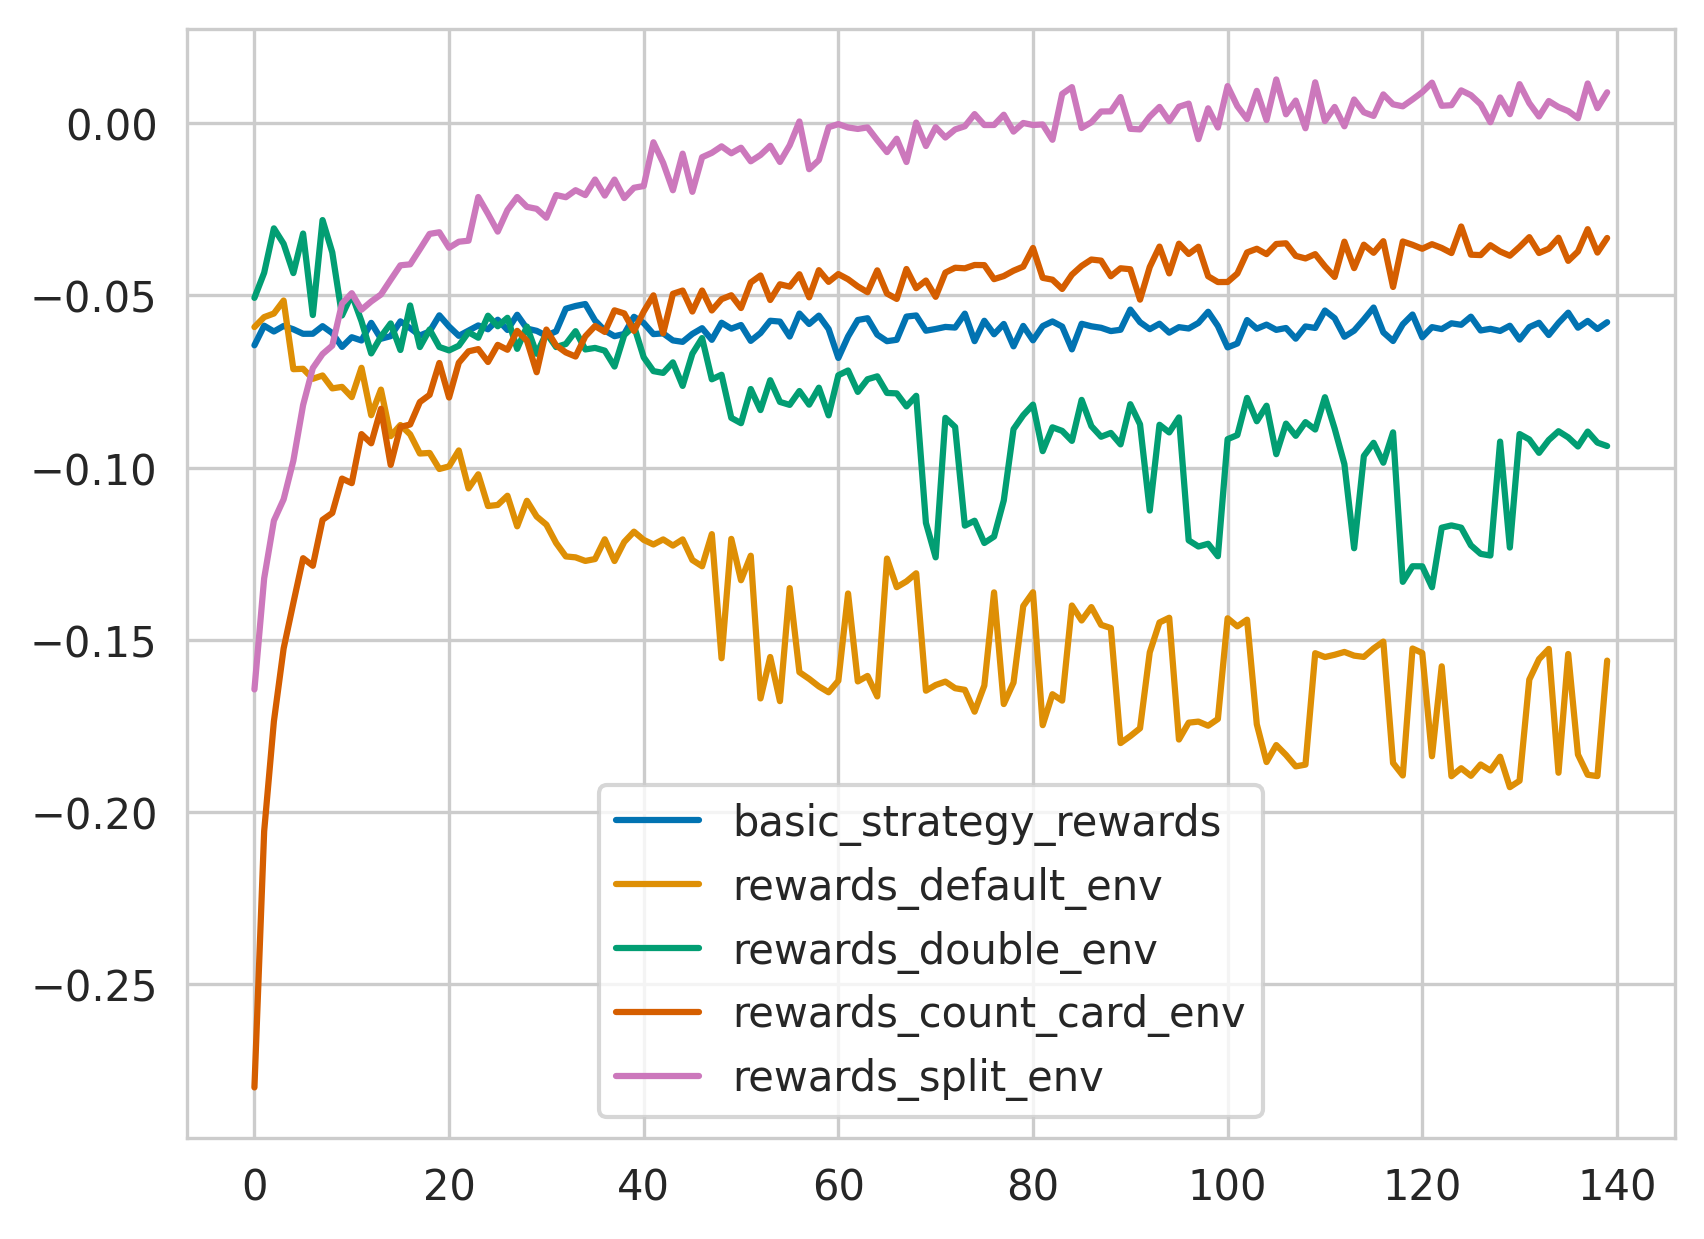

In [ ]:
df = pd.DataFrame(
    {
        "basic_strategy_rewards": basic_strategy_rewards,
        "rewards_default_env": rewards_default_env,
        "rewards_double_env": rewards_double_env,
        "rewards_count_card_env": rewards_count_card_env,
        "rewards_split_env": rewards_split_env,
        "rewards_count_card_env_plus_minus": rewards_count_card_env_plus_minus,
        "rewards_split_env_plus_minus": rewards_split_env_plus_minus
     }
)
df.to_csv("new_rewards.csv", index=False)
df.plot()